# Introduction
GOAL: To train a model to predict the wildfire risk of properties, using census data as input features and the proximity to fires as a target feature.

Make a note about this being at the county level due to hardware restrictions, and that tract or block group levels would likely improve results.

In [1]:
import pandas as pd
import load_wildfires
import load_census
import load_properties
import gis
import train
import visualize
import sqlalchemy as s

from pathlib import Path
from sql_funcs import SQL

from settings import PATH_DATA

In [2]:
SQL.kill_idle(True)
sql_obj = SQL()


kill_idle: terminated 8 connection(s)


# Load Properties

## Select Properties of Interest

Chosing 300000 properties randomly from US addresses. We will join relevant census data to these addresses. This will probably take awhile, so best to run it overnight.

We don't care about the address itself. We add a census identifier called the GEOID which based on the coordinate's state, county, and tract number.

Using a package that makes use of the [US Census Geocoder API](https://www.census.gov/programs-surveys/geography/technical-documentation/complete-technical-documentation/census-geocoder.html), requests can be in batches of 10,000.

https://pypi.org/project/random-address/

In [3]:
props = load_properties.Properties(sql_obj=sql_obj)
properties = props.get_properties_gpd()
cur_count = properties.shape[0]
desired_count = 300000
if cur_count < desired_count:
    diff = desired_count - cur_count
    print(f"Adding {diff} more properties...")
    props.add_random_properties_geo_first(diff)


300000 properties loaded.


In [4]:
# result = sql_obj.connection.execute(s.text("SELECT property_id, geoid FROM properties LIMIT 5;"))
# for row in result:
#   print(row)
# raise

# Load Features from US Census

2023 US Census Data

Using an API key, we will use the 'census' Python package to interact with the US Govermnent's census API.

In [5]:
import geopandas as gpd

MERGED_PARQUET = PATH_DATA / "merged_properties_census.parquet"

if MERGED_PARQUET.exists():
    print(f"Loading pre-merged data from {MERGED_PARQUET}...")
    combined_gdf = gpd.read_parquet(MERGED_PARQUET)
    print(f"Loaded {len(combined_gdf)} properties with census features.")
else:
    print("No pre-merged file found. Fetching census data from API...")
    census = load_census.CensusData(sql_obj=sql_obj, year=2023, granularity='county')
    combined_gdf = census.merge_census_info(properties)

combined_gdf.head()

Loading pre-merged data from data\merged_properties_census.parquet...
Loaded 300000 properties with census features.


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,B25091_014E,B25091_015E,B25091_016E,B25091_017E,B25091_018E,B25091_019E,B25091_020E,B25091_021E,B25091_022E,B25091_023E
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,0.149341,0.056879,0.033997,0.018242,0.014300,0.010256,0.009368,0.009005,0.024570,0.008219
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,0.097369,0.057454,0.015119,0.017236,0.028122,0.005745,0.000000,0.000000,0.008769,0.000000
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,0.250290,0.074493,0.043701,0.019570,0.014042,0.006302,0.011969,0.013102,0.039002,0.012328
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,0.153632,0.041678,0.019031,0.010505,0.007374,0.005141,0.002201,0.003925,0.011086,0.002309
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,0.156607,0.074042,0.040440,0.022883,0.012523,0.011175,0.007729,0.009077,0.024818,0.002424


In [6]:
# Census merge is now handled in the cell above.
# If the pipeline was run first, data loads from parquet in seconds.
# Otherwise, it falls back to fetching from the Census API.

# Load Wildfire GIS Data for 2024

We will use point data from the Visible Infrared Imaging Radiometer Suite (VIIRS). A valid alternative is using burn boundary data. There are a few different data sources we could use, but in the interest of (portfolio) simplicity we'll use just the VIIRS.

N:B: May be a good chance to practice using AWS DB storage and retrieval?

In [7]:
TARGETS_PARQUET = PATH_DATA / "targets_features.parquet"

if TARGETS_PARQUET.exists():
    print(f"Loading pre-computed targets+features from {TARGETS_PARQUET}...")
    targets_features = gpd.read_parquet(TARGETS_PARQUET)
    # Reconstruct proximity column list for drop_cols later
    census_cols = [c for c in targets_features.columns if c.startswith("B")]
    proximity_cols = [c for c in targets_features.columns
                      if c not in census_cols and c not in ["geometry", "geoid"]]
    print(f"Loaded {len(targets_features)} rows x {targets_features.shape[1]} cols "
          f"({len(proximity_cols)} proximity features)")
else:
    print("No pre-computed file found. Running wildfire ETL inline...")
    wildfires = load_wildfires.WildfireData(sql_obj=sql_obj)
    proximity_features = gis.calc_all_features_parallel(combined_gdf, wildfires.data, n_jobs=5)
    targets_features = pd.concat([combined_gdf, proximity_features], axis=1)
    proximity_cols = list(proximity_features.columns)

targets_features.head()

No pre-computed file found. Running wildfire ETL inline...
Loading previously extracted wildfire data from: ['J1V-C2' 'J1V-C2,SV-C2' 'J1V-C2,J2V-C2' 'J1V-C2,J2V-C2,SV-C2' 'J2V-C2'
 'J2V-C2,SV-C2' 'SV-C2']
Loading cached GIS features from gis_features_4d24d2cad2ce.parquet


,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,450.574494,6.0,19.0,33.0,101.0,79.995714,235.806667,734.320667,3393.200694,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,214.503120,0.0,2.0,14.0,15.0,0.000000,183.780000,646.620000,264.548333,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,318.361190,0.0,0.0,32.0,137.0,0.000000,0.000000,836.818500,3150.233841,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,63.273227,0.0,0.0,7.0,72.0,0.000000,0.000000,79.770000,1617.107798,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,18.885996,0.0,0.0,3.0,12.0,0.000000,0.000000,45.120000,143.805000,31.090475


In [8]:
# Visualize wildfire locations
# wildfire_map = wildfires.visualize_data(save_path=Path("figures/wildfires_map.html"))
# wildfire_map

## Create Targets (Wildfire Proximity Score)

Give Each Property a Wildfire Risk Score based on the proximity to wildfires.

TODO: List/describe the various options given for targets.


In [9]:
# Proximity features are now loaded from the pipeline output above.
# If running inline, they were computed in the cell above.

In [10]:
targets_features.head()

,geoid,geometry,B01001A_003E,B01001A_004E,B01001A_005E,B01001A_006E,B01001A_007E,B01001A_008E,B01001A_009E,B01001A_010E,...,exp_decay_score,fire_count_0_10km,fire_count_10_25km,fire_count_25_50km,fire_count_50_100km,fire_FRP_0_10km,fire_FRP_10_25km,fire_FRP_25_50km,fire_FRP_50_100km,nearest_fire_km
0,370519802001,POINT (1531098.378 1482135.679),0.005634,0.005158,0.004979,0.002779,0.003275,0.012190,0.009063,0.007168,...,450.574494,6.0,19.0,33.0,101.0,79.995714,235.806667,734.320667,3393.200694,1.147839
1,37029950102,POINT (1778379.625 1640812.658),0.010473,0.012120,0.006818,0.002734,0.004611,0.005335,0.004347,0.008991,...,214.503120,0.0,2.0,14.0,15.0,0.000000,183.780000,646.620000,264.548333,20.812553
2,220730052042,POINT (357641.112 1063055.975),0.005941,0.005936,0.007604,0.004302,0.002603,0.006824,0.006378,0.007104,...,318.361190,0.0,0.0,32.0,137.0,0.000000,0.000000,836.818500,3150.233841,27.607862
3,371830537131,POINT (1539679.197 1565350.402),0.005542,0.006388,0.006605,0.004311,0.002699,0.006203,0.007738,0.008328,...,63.273227,0.0,0.0,7.0,72.0,0.000000,0.000000,79.770000,1617.107798,27.845692
4,261614480001,POINT (981423.366 2209882.216),0.005367,0.005576,0.006357,0.004035,0.006811,0.014888,0.009703,0.008705,...,18.885996,0.0,0.0,3.0,12.0,0.000000,0.000000,45.120000,143.805000,31.090475


In [11]:
# # Visualize properties colored by wildfire risk, with wildfire locations
# combined_map = visualize.create_combined_map(
#     targets_features,
#     wildfires.data,
#     risk_column="nearest_fire_km",
#     save_path=Path("figures/risk_map.html")
# )
# combined_map

# Machine Learning Considerations
## Scoring Methods

For the float risk score, we can use Mean Squared Error (MSE) or Root Mean Squared Error (RMSE). Since it's quadratic in difference between observations and predictions deviations, MSE strongly penalizes large misses, which would be expensive for the insurance company.

For the risk category counts, they appear to be Poisson distributed, so a Poisson loss-function is appropriate.

For any classification model with the binned risk categories, we want to make large misses costly (i.e. predicting a 1 when the category is a 10), since these would also be very costly to the insurance company. To be honest, MSE will work here as well, since the categories are just 

# Model Machine Learning


NB: A good chance to make use of AWS compute.


## Split Data into Features/Targets

We use `nearest_fire_km` as the target — the distance in kilometres to the nearest wildfire detection. With the full 300k-property dataset, `exp_decay_score` (which captures both proximity and density of nearby fires) would be a better choice, but the small 119-property test set has nearly zero variance in decay score because all properties are ~360 km from the nearest fire.

All other proximity-derived columns are dropped so the model only sees census features as inputs.

In [12]:
TARGET_COL = "nearest_fire_km"

# All proximity features are derived from the same wildfire data — drop them
# so the model only sees census features as inputs.
drop_cols = ["geometry", "geoid"] + [c for c in proximity_cols if c != TARGET_COL]

# SAVE TO PARQUET FOR AWS
targets_features.drop(columns=drop_cols).to_parquet(PATH_DATA/"model_joined.parquet")

# Preprocessing with adaptive imputation based on missingness analysis
# - MCAR features: SimpleImputer (median) - fast
# - MAR features: IterativeImputer - preserves correlations
X_train, X_test, y_train, y_test, feature_names, pipeline = train.preprocess_with_cache(
    targets_features,
    TARGET_COL,
    drop_cols,
    nan_threshold=0.45,
    corr_threshold=0.85,
    mar_corr_threshold=0.1,  # Features with missingness corr > 0.1 use IterativeImputer
    use_cache=True,
)


print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: {y_train.min():.4f} – {y_train.max():.4f}")
print(f"Target std:   {y_train.std():.6f}")
print(f"Target mean:  {y_train.mean():.4f}")

Loading cached preprocessing from preprocess_d270d9dd766b.pkl
  Loaded 556 features from cache
Train: (240000, 556), Test: (60000, 556)
Target range: 0.0329 – 315.4585
Target std:   27.494053
Target mean:  24.4749


In [13]:
# Diagnostic: check if the target has meaningful variance
cv = y_train.std() / y_train.mean() * 100  # coefficient of variation
print(f"Coefficient of variation: {cv:.4f}%")
if cv < 1.0:
    print(
        f"WARNING: Target has near-zero variance (CV={cv:.4f}%). "
        f"All properties are ~{y_train.mean():.1f} km from the nearest fire. "
        f"Models will appear to have perfect accuracy but are not learning meaningful patterns. "
        f"Scale to 300k properties for geographic diversity."
    )

Coefficient of variation: 112.3358%


## Preprocessing

Drop high-NaN columns, remove correlated features, then impute + scale. All steps are fit on training data only to prevent leakage.

**Adaptive Imputation:** The preprocessing analyzes each feature's missingness mechanism:
- **MCAR** (Missing Completely At Random): Uses `SimpleImputer(median)` - fast, O(n)
- **MAR** (Missing At Random): Uses `IterativeImputer` - preserves feature correlations

**Caching:** Results are cached to `data/cache/preprocess_{hash}.pkl`. Re-runs with unchanged data load from cache in <1s.

In [14]:
# Preprocessing is now handled by train.preprocess_with_cache() above
# which performs:
#   1. Missingness analysis (MCAR vs MAR detection)
#   2. Adaptive imputation (SimpleImputer for MCAR, IterativeImputer for MAR)
#   3. StandardScaler
# All results are cached - re-runs with unchanged data load in <1s

## Model Training


### RandomForestRegressor


In [15]:
rfr_search = train.train_random_forest(X_train, y_train, n_iter=20, cv=5, n_jobs=10)  # Runs on CPU
print(f"Best RF params: {rfr_search.best_params_}")

rfr_metrics = train.evaluate_model(rfr_search.best_estimator_, X_train, X_test, y_train, y_test)
print(f"RF Train RMSE: {rfr_metrics['train_rmse']:.8f}")
print(f"RF Test  RMSE: {rfr_metrics['test_rmse']:.8f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best RF params: {'max_depth': 44, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 927}
RF Train RMSE: 8.53712090
RF Test  RMSE: 8.74250298


### XGBoost


In [16]:
xgb_search = train.train_xgboost(X_train, y_train, n_iter=20, cv=5, n_jobs=2)  # Runs on dGPU
print(f"Best XGB params: {xgb_search.best_params_}")

xgb_metrics = train.evaluate_model( xgb_search.best_estimator_, X_train, X_test, y_train, y_test)
print(f"XGB Train RMSE: {xgb_metrics['train_rmse']:.8f}")
print(f"XGB Test  RMSE: {xgb_metrics['test_rmse']:.8f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\jdcf5\anaconda3\envs\GIS\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGB params: {'colsample_bytree': np.float64(0.7355789407775537), 'gamma': np.float64(0.42855130361271904), 'learning_rate': np.float64(0.10614654887463763), 'max_depth': 11, 'min_child_weight': 2, 'n_estimators': 659, 'reg_alpha': np.float64(0.3544317346711524), 'reg_lambda': np.float64(0.5498989637627353), 'subsample': np.float64(0.9187783443855757)}
XGB Train RMSE: 8.53752339
XGB Test  RMSE: 8.74332428


## Extract Feature Weights

To give the results human-readable explanations of the correlations that may be causations.

In [17]:
#Pick the better model
if xgb_metrics["test_rmse"] <= rfr_metrics["test_rmse"]:
    best_model = xgb_search.best_estimator_
    lesser_model = rfr_search.best_estimator_
    print("Best model: XGBoost")
    best_model_str = 'XGB'
    lesser_model_str = 'RFR'
else:
    best_model = rfr_search.best_estimator_
    lesser_model = xgb_search.best_estimator_
    print("Best model: RandomForest")
    best_model_str = 'RFR'
    lesser_model_str = 'XGB'

feature_names = [load_census.census_code_to_label(x) for x in feature_names]

top_features = train.extract_feature_importance(best_model, feature_names, top_n=10)
print(f"\nTop 10 features:\n{top_features}")

Best model: RandomForest

Top 10 features:
House Heating Fuel: Fuel oil, kerosene, etc.                                                                        0.034938
Place of Birth by Nativity and Citizenship Status: Native:!!Born in other state in the United States:!!Northeast    0.023295
House Heating Fuel: Electricity                                                                                     0.019478
Total Population in Occupied Housing Units by Tenure by Units in Structure: Owner occupied:!!2 to 4                 0.017732
Place of Birth by Nativity and Citizenship Status: Foreign-born:!!Naturalized U.S. citizen!!Northern America        0.012577
Place of Birth by Nativity and Citizenship Status: Native:!!Born in other state in the United States:!!Midwest      0.010197
Units in Structure (White Alone Householder): 3 or 4                                                                0.009865
Tenure by Units in Structure: Renter-occupied housing units:!!1, detached         

Figure saved to figures\feature_importance.png


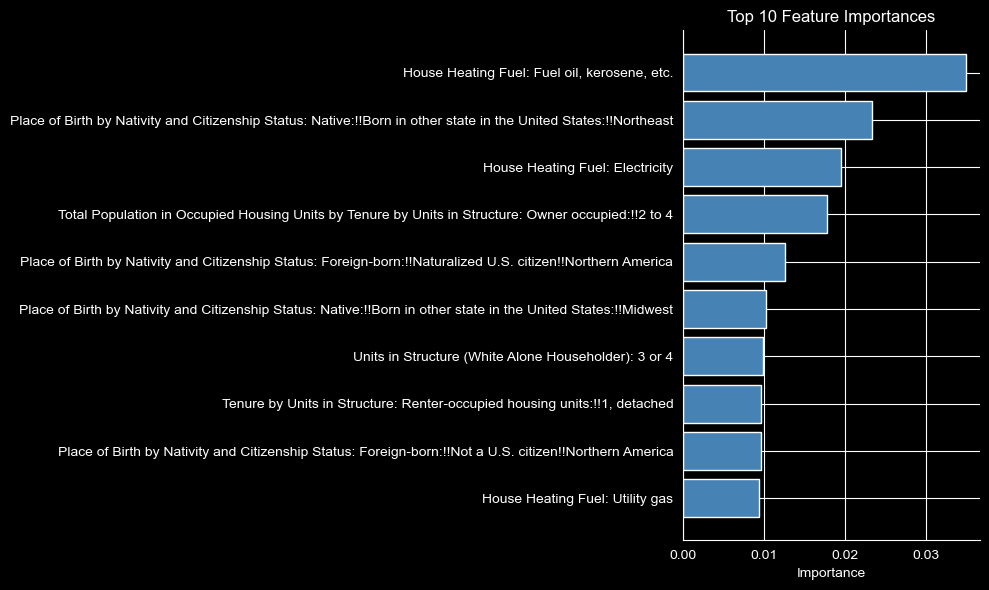

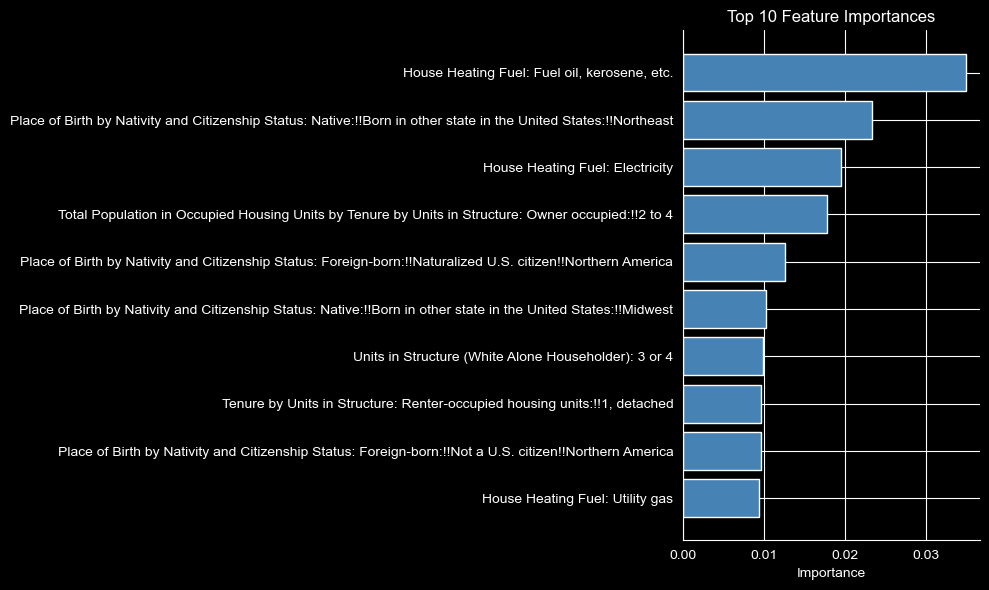

In [18]:
# Feature importance bar chart
fig_importance = visualize.plot_feature_importance(
    top_features, 
    title="Top 10 Feature Importances",
    save_path=Path("figures/feature_importance.png")
)
fig_importance

Figure saved to figures\actual_vs_predicted.png


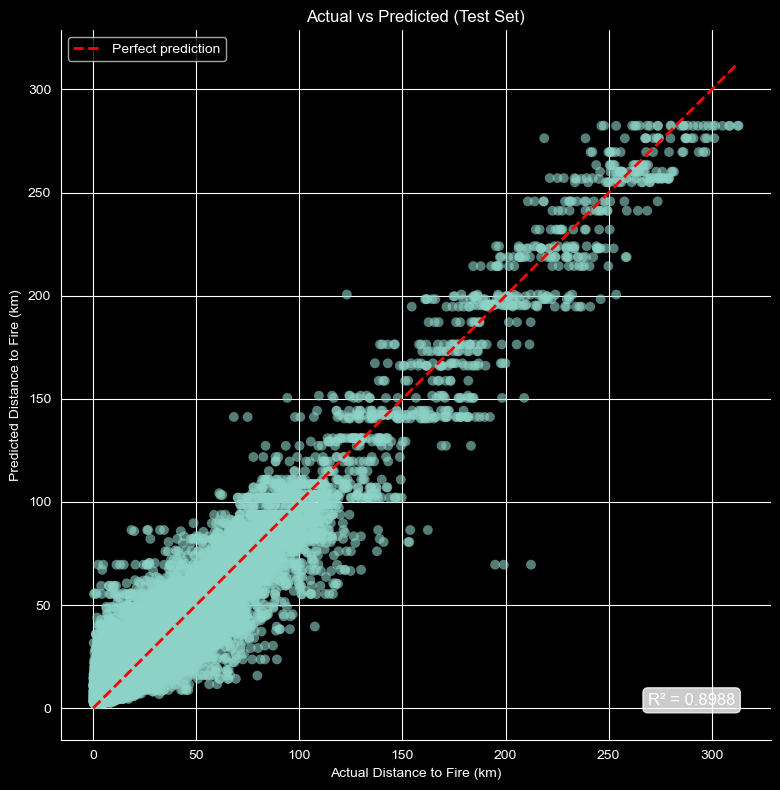

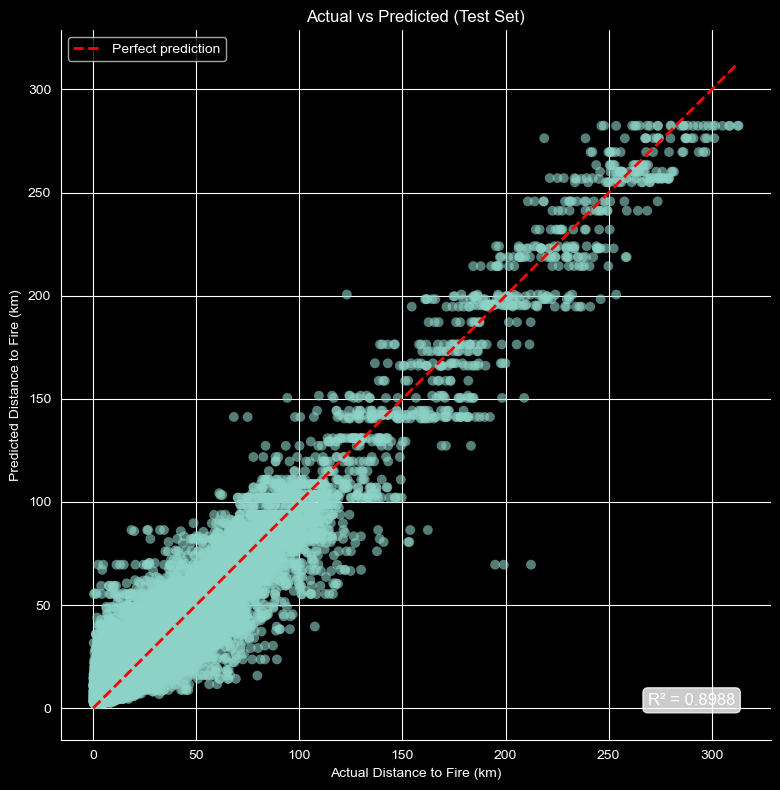

In [19]:
# Actual vs Predicted scatter plot
y_pred = best_model.predict(X_test)

fig_scatter = visualize.plot_actual_vs_predicted(
    y_test.values, 
    y_pred,
    title="Actual vs Predicted (Test Set)",
    xlabel="Actual Distance to Fire (km)",
    ylabel="Predicted Distance to Fire (km)",
    save_path=Path("figures/actual_vs_predicted.png")
)
fig_scatter

In [21]:
best_model_path = Path("Models") / f"best_model_{best_model_str}.pkl"
train.save_model(best_model, best_model_path, pipeline=pipeline, feature_names=feature_names)
print(f"Best model saved to {best_model_path}")

lesser_model_path = Path("Models") / f"lesser_model_{lesser_model_str}.pkl"
train.save_model(lesser_model, lesser_model_path, pipeline=pipeline, feature_names=feature_names)
print(f"Lesser model saved to {lesser_model_path}")


Best model saved to Models\best_model_RFR.pkl
Lesser model saved to Models\lesser_model_XGB.pkl


# Conclusion